# Batch Normalization Etkisinin Analizi

Bu projede Batch Normalization’ın model performansı üzerindeki etkisi MNIST veri seti kullanılarak incelenmiştir.

## 1. Gerekli Kütüphanelerin Yüklenmesi

Projede kullanılacak kütüphaneler yüklenmektedir. TensorFlow model kurmak, matplotlib ise sonuçları görselleştirmek için kullanılacaktır.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Flatten

## 2. Veri Yükleme

MNIST veri seti yüklenmektedir. Bu veri seti el yazısı rakam görüntülerinden oluşmaktadır.

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Eğitim veri boyutu:", X_train.shape)
print("Test veri boyutu:", X_test.shape)

Eğitim veri boyutu: (60000, 28, 28)
Test veri boyutu: (10000, 28, 28)


## 3. Veri Ön İşleme

Görüntü verileri normalize edilerek modelin daha sağlıklı öğrenmesi sağlanır. Ayrıca veriler modele uygun formata dönüştürülür.

In [ ]:
# Normalizasyon (0–255 → 0–1 arası)
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Örnek veri şekli:", X_train.shape)

Örnek veri şekli: (60000, 28, 28)


## 4. Model Kurulumu

Batch Normalization içeren ve içermeyen iki farklı model oluşturulacaktır. Böylece iki modelin performansı karşılaştırılabilecektir.

In [ ]:
# Batch Normalization OLMAYAN model
model_without_bn = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_without_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Batch Normalization OLAN model
model_with_bn = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(10, activation='softmax')
])

model_with_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 5. Model Eğitimi

Oluşturulan iki model eğitilerek öğrenme performansları karşılaştırılacaktır.

In [ ]:
history_without_bn = model_without_bn.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

history_with_bn = model_with_bn.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9308 - loss: 0.2362 - val_accuracy: 0.9573 - val_loss: 0.1288
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9706 - loss: 0.0996 - val_accuracy: 0.9668 - val_loss: 0.1077
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9779 - loss: 0.0709 - val_accuracy: 0.9737 - val_loss: 0.0884
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9831 - loss: 0.0534 - val_accuracy: 0.9773 - val_loss: 0.0797
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9861 - loss: 0.0433 - val_accuracy: 0.9771 - val_loss: 0.0769
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9889 - loss: 0.0350 - val_accuracy: 0.9742 - val_loss: 0.0896
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9906 - loss: 0.0287 - val_accuracy: 0.9770 - val_loss: 0.0794
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9919 - loss: 0.0241 

## 6. Sonuçların Gösterimi

Eğitim sürecinde elde edilen doğruluk değerleri grafik ile karşılaştırılmaktadır.

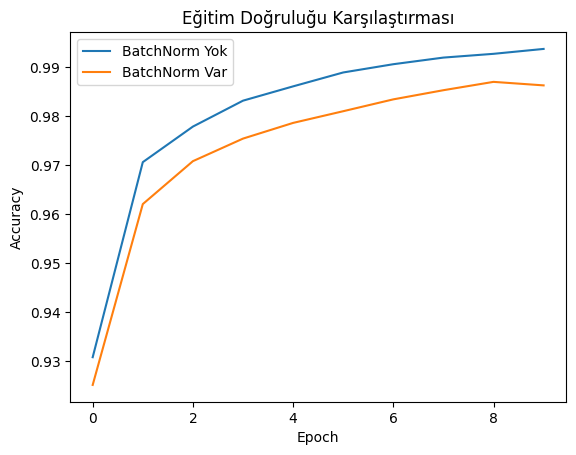

In [ ]:
plt.plot(history_without_bn.history['accuracy'], label='BatchNorm Yok')
plt.plot(history_with_bn.history['accuracy'], label='BatchNorm Var')

plt.title('Eğitim Doğruluğu Karşılaştırması')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 7. Sonuç Değerlendirmesi

Modellerin test performansları karşılaştırılmaktadır.

In [ ]:
loss1, acc1 = model_without_bn.evaluate(X_test, y_test, verbose=0)
loss2, acc2 = model_with_bn.evaluate(X_test, y_test, verbose=0)

print("BatchNorm YOK Accuracy:", acc1)
print("BatchNorm VAR Accuracy:", acc2)

BatchNorm YOK Accuracy: 0.9768000245094299
BatchNorm VAR Accuracy: 0.978600025177002


### Yorum

Elde edilen sonuçlara göre her iki model de yüksek doğruluk elde etmiştir. Sonuçların birbirine yakın çıkmasının nedeni veri setinin kolay olması ve her iki modelin de başarılı şekilde öğrenebilmesidir. Batch Normalization’ın etkisi doğruluk farkından çok öğrenme sürecindeki stabilite üzerinden değerlendirilmiştir.